# Member 3: evaluation, annotation and reporting

Owns Sections 7–9.

This notebook is part of the same stage-classification workflow. It uses the original fixed split and settings. Run cells from top to bottom. The original filtering/transformation of CpGs, SEX mapping and AGE units remain unverified. These are exploratory candidate markers, not validated clinical biomarkers.

In Colab, start a fresh CPU runtime and run all cells in order. The setup cell aligns scikit-learn to 1.8.0. The input cell downloads `development.joblib`, `test_holdout.joblib`, and `locked_models.joblib` directly from this GitHub repository and falls back to a Colab upload picker only if needed. No manual path edits are required.

Inputs: `development.joblib`, `test_holdout.joblib`, and `locked_models.joblib`. Optional: verified `CpG_annotation.csv`. Outputs: held-out evaluation figures and final tables. This notebook never retrains the models.

The original combined notebook already exposed test results. Reproducing its locked analysis is useful, but further changes guided by those results are exploratory.

## Colab setup and input loading
Run these cells first. Required repository inputs are downloaded automatically from GitHub when they are not already present. Existing local files are reused.


In [1]:
# Run this cell first, before importing analysis packages.
import sys
import subprocess
import importlib.util
from importlib.metadata import version, PackageNotFoundError

try:
    from google.colab import files as colab_files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# All three members use this version to share fitted scikit-learn models.
TARGET_SKLEARN = '1.8.0'
try:
    installed_sklearn = version('scikit-learn')
except PackageNotFoundError:
    installed_sklearn = None

requirements = []
if installed_sklearn != TARGET_SKLEARN:
    requirements.append('scikit-learn==' + TARGET_SKLEARN)
for module, package in [('numpy','numpy'), ('pandas','pandas'), ('scipy','scipy'),
                        ('matplotlib','matplotlib'), ('seaborn','seaborn'), ('joblib','joblib')]:
    if importlib.util.find_spec(module) is None:
        requirements.append(package)
if requirements:
    # If you already imported a different sklearn version, start a fresh session first.
    if 'sklearn' in sys.modules and installed_sklearn != TARGET_SKLEARN:
        raise RuntimeError('Start a fresh runtime/session and run this setup cell first.')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *requirements])
    importlib.invalidate_caches()
print('Environment:', 'Google Colab' if IN_COLAB else 'Local Python')
print('scikit-learn:', version('scikit-learn'))


Environment: Local Python
scikit-learn: 1.8.0


In [2]:
from pathlib import Path
from urllib.request import urlopen
import io
import pandas as pd

REPO_RAW_BASE = 'https://raw.githubusercontent.com/UmairSeemab/CRG-groupProject/main'
REPO_INPUT_URLS = {
    'Xsurv.csv': f'{REPO_RAW_BASE}/Xsurv.csv',
    'development.joblib': f'{REPO_RAW_BASE}/development.joblib',
    'test_holdout.joblib': f'{REPO_RAW_BASE}/test_holdout.joblib',
    'locked_models.joblib': f'{REPO_RAW_BASE}/locked_models.joblib',
}

def locate_input(filename):
    return next((p for p in [Path('checkpoints') / filename, Path(filename)] if p.is_file()), None)

def validate_csv_bytes(payload):
    candidate = pd.read_csv(io.BytesIO(payload), index_col=0)
    if len(candidate) != 320 or not {'AGE', 'SEX', 'Stage'}.issubset(candidate.columns):
        raise ValueError('This is not the expected 320-row Xsurv dataset.')
    if sum(str(c).startswith('cg') for c in candidate.columns) != 197:
        raise ValueError('Expected 197 CpG columns.')
    if set(candidate.Stage.unique()) != {1, 2}:
        raise ValueError('Expected Stage labels 1 and 2.')
    return candidate

def _download_target(filename):
    if filename.endswith('.joblib'):
        Path('checkpoints').mkdir(exist_ok=True)
        return Path('checkpoints') / filename
    return Path(filename)

def download_repo_input(filename):
    url = REPO_INPUT_URLS.get(filename)
    if url is None:
        return False
    try:
        with urlopen(url, timeout=60) as response:
            payload = response.read()
        if filename == 'Xsurv.csv':
            validate_csv_bytes(payload)
        target = _download_target(filename)
        target.write_bytes(payload)
        print(f'Downloaded {filename} from the project GitHub repository.')
        return True
    except Exception as exc:
        print(f'Automatic download failed for {filename}: {exc}')
        return False

def ensure_inputs(required):
    missing = [name for name in required if locate_input(name) is None]

    # First try the public files stored in this GitHub repository.
    for name in list(missing):
        download_repo_input(name)
    missing = [name for name in required if locate_input(name) is None]

    # Fallback for Colab if GitHub is temporarily unavailable or a file has not been uploaded yet.
    if missing and IN_COLAB:
        print('GitHub input unavailable. Upload these files together:', ', '.join(missing))
        uploaded = colab_files.upload()
        for name, payload in uploaded.items():
            filename = Path(name).name
            if filename in required:
                target = _download_target(filename)
                target.write_bytes(payload)
        missing = [name for name in required if locate_input(name) is None]

    if missing:
        raise FileNotFoundError(
            'Required inputs still missing: ' + ', '.join(missing) +
            '. Upload them to the repository root, place them beside the notebook/checkpoints folder, '
            'or rerun this cell and use the Colab upload fallback.'
        )

    if 'Xsurv.csv' in required:
        validate_csv_bytes(locate_input('Xsurv.csv').read_bytes())
    print('Inputs ready:', ', '.join(required))

ensure_inputs(['development.joblib', 'test_holdout.joblib', 'locked_models.joblib'])


Inputs ready: development.joblib, test_holdout.joblib, locked_models.joblib


In [3]:
from pathlib import Path
import sys, json, hashlib, platform, warnings
import numpy as np
import pandas as pd
import scipy, sklearn, matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import (roc_auc_score, balanced_accuracy_score, recall_score,
                             confusion_matrix, roc_curve, precision_recall_curve,
                             average_precision_score, brier_score_loss)
from sklearn.exceptions import ConvergenceWarning

SEED = 42
DATA_PATH = None  # e.g. Path('/your/folder/Xsurv.csv')
OUT = Path('Xsurv_results/member_3')
OUT.mkdir(exist_ok=True, parents=True)
OUTER_FOLDS, INNER_FOLDS = 5, 3
N_BOOTSTRAP = 2000
THRESHOLD = 0.5  # fixed in advance; never optimize on the test set
PANEL_TOLERANCE = 0.02  # descriptive AUC tolerance, not a noninferiority margin
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 180, 'font.size': 10})
versions = {'python': platform.python_version(), 'numpy': np.__version__,
            'pandas': pd.__version__, 'scipy': scipy.__version__,
            'scikit-learn': sklearn.__version__, 'matplotlib': matplotlib.__version__,
            'seaborn': sns.__version__}
print(json.dumps(versions, indent=2))
def table(obj):
    print(obj.to_string() if hasattr(obj, 'to_string') else obj)
def finish(name):
    plt.tight_layout()
    plt.savefig(OUT / (name + '.png'), bbox_inches='tight')
    plt.show()
# Do not silently accept a nonconverged logistic model.
warnings.filterwarnings('error', category=ConvergenceWarning)
import joblib
CHECKPOINTS = Path('checkpoints')
CHECKPOINTS.mkdir(exist_ok=True)
def load_checkpoint(filename):
    path = next((p for p in [CHECKPOINTS/filename, Path(filename)] if p.exists()), None)
    if path is None:
        raise FileNotFoundError(f'Upload {filename} or put it in checkpoints/. Run the preceding member notebook first.')
    # Load only checkpoint files produced by your trusted group: joblib uses pickle.
    bundle = joblib.load(path)
    if bundle['versions']['scikit-learn'] != sklearn.__version__:
        raise RuntimeError('Use the same scikit-learn version as the checkpoint creator: '+bundle['versions']['scikit-learn'])
    return bundle

{
  "python": "3.12.14",
  "numpy": "2.3.5",
  "pandas": "2.2.3",
  "scipy": "1.17.0",
  "scikit-learn": "1.8.0",
  "matplotlib": "3.10.8",
  "seaborn": "0.13.2"
}


In [4]:
development = load_checkpoint('development.joblib')
locked = load_checkpoint('locked_models.joblib')
holdout = load_checkpoint('test_holdout.joblib')
assert len({b['split_id'] for b in [development,locked,holdout]}) == 1, 'Mixed checkpoints: use the same run.'
assert len({b['source_hash'] for b in [development,locked,holdout]}) == 1
assert development['config'] == locked['config'] == holdout['config']
X_test, y_test = holdout['X_test'],holdout['y_test']
assert set(X_test.index).isdisjoint(development['X_dev'].index)
config = locked['config']
SEED, OUTER_FOLDS, INNER_FOLDS = config['seed'],config['outer_folds'],config['inner_folds']
THRESHOLD, PANEL_TOLERANCE, N_BOOTSTRAP = config['threshold'],config['panel_tolerance'],config['n_bootstrap']
final_models = locked['final_models']
feature_columns = locked['feature_columns']
selected_panel_name, winner_name = locked['selected_panel_name'],locked['winner_name']
clinical_name, full_name = locked['clinical_name'],locked['full_name']
locked_names, panel_genes = locked['locked_names'],locked['panel_genes']
final_panel_table, marker_ranking = locked['final_panel_table'],locked['marker_ranking']
cv_results, summary = locked['cv_results'],locked['summary']
audit, split_manifest, high_corr = development['audit'],development['split_manifest'],development['high_corr']
print('Loaded locked models:',locked_names)
print('Test patients:',len(y_test))

def metrics(yy, probability):
    pred = np.asarray(probability) >= THRESHOLD
    return {'ROC_AUC':roc_auc_score(yy,probability),
            'Balanced_accuracy':balanced_accuracy_score(yy,pred),
            'Sensitivity':recall_score(yy,pred,pos_label=1,zero_division=0),
            'Specificity':recall_score(yy,pred,pos_label=0,zero_division=0)}

Loaded locked models: ['Panel 20', 'Combined elastic-net', 'Clinical forest', 'CpG elastic-net']
Test patients: 64


## 7. Final held-out evaluation
Everything above is now fixed. We generate test probabilities once per locked model and calculate metrics at threshold 0.5.

The 95% percentile intervals use 2,000 stratified bootstrap samples of test patients, preserving the observed low/high counts. They quantify test-sample uncertainty conditional on fitted models. They do not include model-selection, training or original preprocessing uncertainty. With only 64 test patients, conclusions may remain imprecise.

The clinical and full-CpG comparisons are descriptive. We do not claim a significant improvement from point estimates alone. Probability calibration is summarized by the Brier score, but not recalibrated on test data.

In [5]:
test_prob = {name:model.predict_proba(X_test[feature_columns[name]])[:,1] for name,model in final_models.items()}
test_point = pd.DataFrame({name:{**metrics(y_test,p),'Average_precision':average_precision_score(y_test,p),
                                'Brier_score':brier_score_loss(y_test,p)} for name,p in test_prob.items()}).T
table(test_point.round(3))
rng = np.random.default_rng(SEED)
y_arr = y_test.to_numpy()
low_idx, high_idx = np.flatnonzero(y_arr==0), np.flatnonzero(y_arr==1)
boot_idx = [np.concatenate([rng.choice(low_idx,len(low_idx),replace=True),rng.choice(high_idx,len(high_idx),replace=True)]) for _ in range(N_BOOTSTRAP)]
interval_records=[]
bootstrap_auc = {}
for name,p in test_prob.items():
    samples = pd.DataFrame([metrics(y_arr[ix],p[ix]) for ix in boot_idx])
    bootstrap_auc[name] = samples.ROC_AUC.to_numpy()
    for metric in samples:
        lo,hi = np.quantile(samples[metric],[0.025,0.975])
        interval_records.append({'Model':name,'Metric':metric,'Estimate':test_point.loc[name,metric], 'Lower_95':lo,'Upper_95':hi})
test_intervals = pd.DataFrame(interval_records)
table(test_intervals.round(3))
delta = bootstrap_auc[selected_panel_name]-bootstrap_auc[clinical_name]
print('Panel minus clinical AUC:', round(test_point.loc[selected_panel_name,'ROC_AUC']-test_point.loc[clinical_name,'ROC_AUC'],3))
print('Paired bootstrap 95% interval:',np.round(np.quantile(delta,[0.025,0.975]),3))

                      ROC_AUC  Balanced_accuracy  Sensitivity  Specificity  Average_precision  Brier_score
Panel 20                0.609              0.511        0.667        0.355              0.666        0.260
Combined elastic-net    0.555              0.575        0.667        0.484              0.593        0.291
Clinical forest         0.451              0.531        0.545        0.516              0.477        0.288
CpG elastic-net         0.522              0.481        0.576        0.387              0.570        0.302
                   Model             Metric  Estimate  Lower_95  Upper_95
0               Panel 20            ROC_AUC     0.609     0.467     0.743
1               Panel 20  Balanced_accuracy     0.511     0.401     0.623
2               Panel 20        Sensitivity     0.667     0.485     0.818
3               Panel 20        Specificity     0.355     0.194     0.516
4   Combined elastic-net            ROC_AUC     0.555     0.414     0.696
5   Combined elastic-

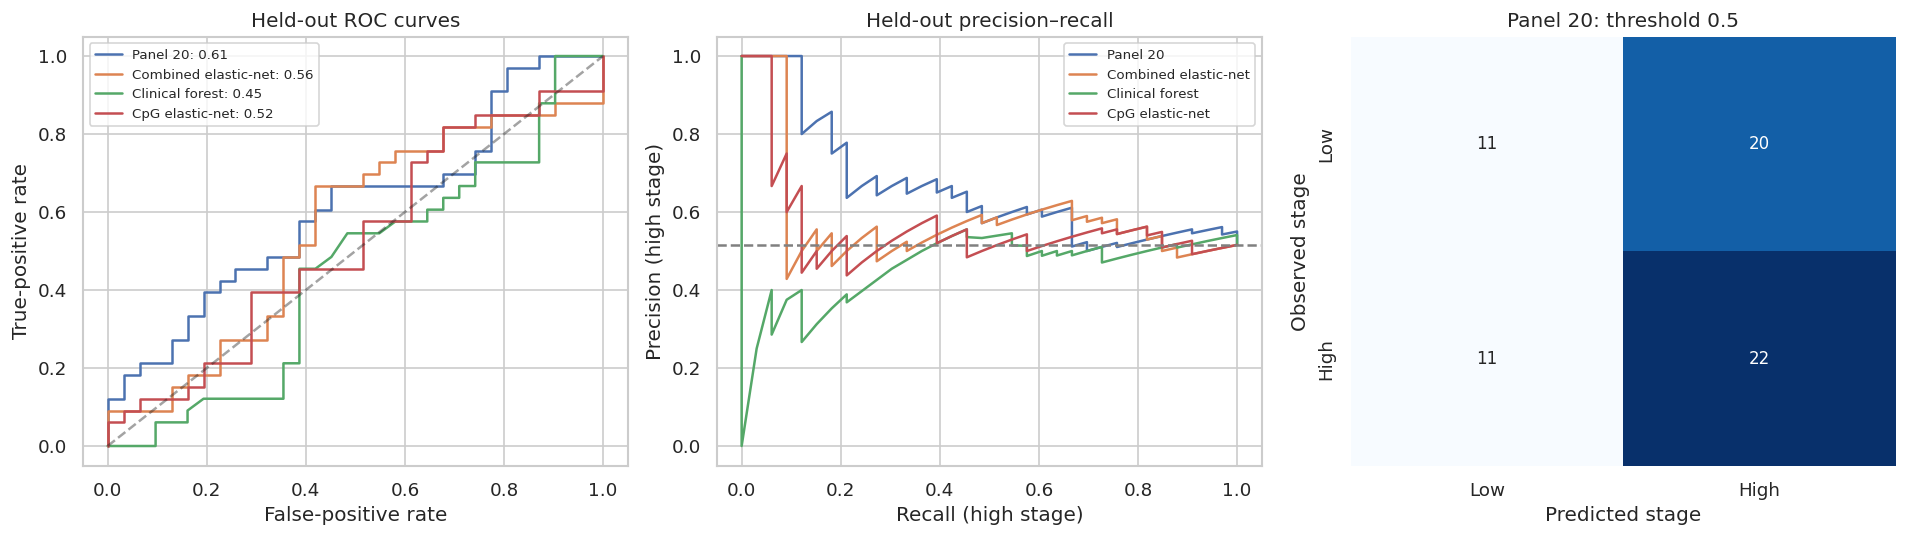

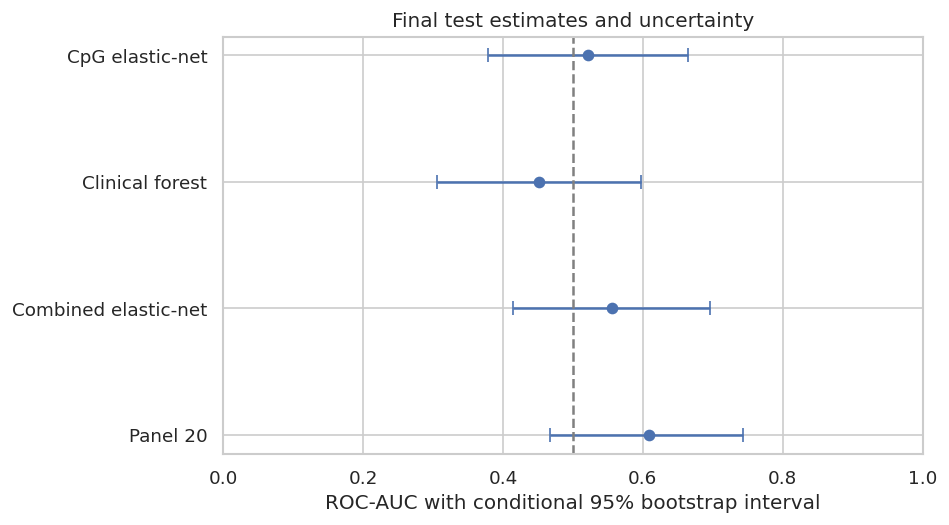

In [6]:
fig, axes = plt.subplots(1,3,figsize=(16,4.6))
for name,p in test_prob.items():
    fpr,tpr,_ = roc_curve(y_test,p)
    axes[0].plot(fpr,tpr,label=f'{name}: {roc_auc_score(y_test,p):.2f}')
    precision,recall,_ = precision_recall_curve(y_test,p)
    axes[1].plot(recall,precision,label=name)
axes[0].plot([0,1],[0,1],'k--',alpha=0.4)
axes[0].set(xlabel='False-positive rate',ylabel='True-positive rate',title='Held-out ROC curves')
axes[0].legend(fontsize=8)
axes[1].axhline(y_test.mean(),color='gray',linestyle='--')
axes[1].set(xlabel='Recall (high stage)',ylabel='Precision (high stage)',title='Held-out precision–recall')
axes[1].legend(fontsize=8)
cm = confusion_matrix(y_test,test_prob[selected_panel_name]>=THRESHOLD,labels=[0,1])
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',cbar=False,xticklabels=['Low','High'],yticklabels=['Low','High'],ax=axes[2])
axes[2].set(xlabel='Predicted stage',ylabel='Observed stage',title=f'{selected_panel_name}: threshold {THRESHOLD}')
finish('09_test_performance')

plt.figure(figsize=(8,4.5))
ci = test_intervals.query("Metric == 'ROC_AUC'").set_index('Model')
plt.errorbar(ci.Estimate, np.arange(len(ci)), xerr=[ci.Estimate-ci.Lower_95,ci.Upper_95-ci.Estimate],fmt='o',capsize=4)
plt.yticks(np.arange(len(ci)),ci.index); plt.axvline(0.5,color='gray',linestyle='--')
plt.xlim(0,1); plt.xlabel('ROC-AUC with conditional 95% bootstrap interval')
plt.title('Final test estimates and uncertainty')
finish('10_test_intervals')

## 8. Biological annotation without invented mappings
The CSV contains probe IDs but no assay platform, genome build, gene mapping or genomic coordinates. Automatic gene assignment would be unreliable without a matching annotation manifest. Therefore this section is executable but conditional: it merges a supplied, verified annotation CSV if present; otherwise it exports an explicitly unresolved annotation table.

To complete this step, confirm the assay and obtain its matching manifest from the original data provider or manufacturer. Prepare `CpG_annotation.csv` with one row per CpG and these columns: `CpG`, `Gene`, `Chromosome`, `Position`, `Genome_build`, `Annotation_source`. Preserve multiple mapped genes within the Gene field. A nearest-gene label is not proof that a CpG regulates that gene. Do not infer methylation direction from the coefficient until the value transformation is documented.

In [7]:
ANNOTATION_PATH = Path('CpG_annotation.csv')
annotation_columns = ['Gene','Chromosome','Position','Genome_build','Annotation_source']
if ANNOTATION_PATH.exists():
    annotation = pd.read_csv(ANNOTATION_PATH,dtype=str)
    assert set(['CpG']+annotation_columns).issubset(annotation.columns)
    assert annotation.CpG.is_unique, 'Consolidate multiple mappings into one row per CpG.'
    annotated_panel = final_panel_table.merge(annotation[['CpG']+annotation_columns],on='CpG',how='left',validate='one_to_one')
    annotated_panel['Annotation_status'] = np.where(annotated_panel.Annotation_source.notna(),'Provided mapping; verify source','Unresolved')
else:
    annotated_panel = final_panel_table.copy()
    for c in annotation_columns: annotated_panel[c] = pd.NA
    annotated_panel['Annotation_status'] = 'Unresolved: platform-matched annotation required'
print('Annotation status:'); table(annotated_panel[['CpG','Gene','Annotation_status']])

Annotation status:
           CpG  Gene                                 Annotation_status
0   cg17975663  <NA>  Unresolved: platform-matched annotation required
1   cg05044414  <NA>  Unresolved: platform-matched annotation required
2   cg07628705  <NA>  Unresolved: platform-matched annotation required
3   cg08335389  <NA>  Unresolved: platform-matched annotation required
4   cg10931252  <NA>  Unresolved: platform-matched annotation required
5   cg06520003  <NA>  Unresolved: platform-matched annotation required
6   cg02257405  <NA>  Unresolved: platform-matched annotation required
7   cg07753583  <NA>  Unresolved: platform-matched annotation required
8   cg01617071  <NA>  Unresolved: platform-matched annotation required
9   cg10376161  <NA>  Unresolved: platform-matched annotation required
10  cg11593482  <NA>  Unresolved: platform-matched annotation required
11  cg15157581  <NA>  Unresolved: platform-matched annotation required
12  cg07502417  <NA>  Unresolved: platform-matched annotat

## 9. Export results and summarize the evidence
Exports include the split manifest, fold-level results, full marker ranking, locked panel, test predictions and uncertainty intervals. Re-running preserves the seed but software-version changes can affect results. A separate external cohort is required to assess transportability. Do not rerun with different seeds until a favorable test result appears.

Use the generated conclusion below to report what this run actually found. A high internal score does not resolve unknown upstream filtering, batch effects, independence or clinical utility.

In [8]:
outputs = {'data_audit':audit.rename('value').to_frame(), 'split_manifest':split_manifest,
           'high_correlations_development':high_corr,'nested_cv_folds':cv_results,
           'nested_cv_summary':summary, 'marker_ranking':marker_ranking,
           'final_panel':annotated_panel, 'test_metrics':test_point,'test_intervals':test_intervals}
for name,frame in outputs.items(): frame.to_csv(OUT/(name+'.csv'),index=name in ['data_audit','nested_cv_summary','test_metrics'])
predictions = pd.DataFrame({'row_id':X_test.index,'Stage_original':y_test.to_numpy()+1})
for name,p in test_prob.items(): predictions[name+'_prob_high'] = p
predictions.to_csv(OUT/'test_predictions.csv',index=False)
manifest = {'seed':SEED,'test_fraction':0.2,'threshold':THRESHOLD,'outer_folds':OUTER_FOLDS,
            'inner_folds':INNER_FOLDS,'panel_tolerance':PANEL_TOLERANCE,'selected_panel':selected_panel_name,
            'winner':winner_name,'locked_models':locked_names,'selected_CpGs':panel_genes.tolist(),
            'parameters':locked['best_parameters'],'versions':versions,
            'input_sha256':locked['source_hash']}
(OUT/'analysis_manifest.json').write_text(json.dumps(manifest,indent=2))
r = test_intervals.query("Model == @selected_panel_name and Metric == 'ROC_AUC'").iloc[0]
print(f'Locked panel: {selected_panel_name}; {len(panel_genes)} CpGs.')
print(f'Internal held-out AUC: {r.Estimate:.3f} (conditional bootstrap 95% interval {r.Lower_95:.3f}–{r.Upper_95:.3f}).')
print(f'Clinical comparator AUC: {test_point.loc[clinical_name,"ROC_AUC"]:.3f}.')
print(f'Full-CpG comparator AUC: {test_point.loc[full_name,"ROC_AUC"]:.3f}.')
print('This run provides candidate stage markers and internal predictive evidence only.')
print('Original CpG filtering, value transformation and biological annotation still need verification.')
print('Export directory:',OUT.resolve())

Locked panel: Panel 20; 20 CpGs.
Internal held-out AUC: 0.609 (conditional bootstrap 95% interval 0.467–0.743).
Clinical comparator AUC: 0.451.
Full-CpG comparator AUC: 0.522.
This run provides candidate stage markers and internal predictive evidence only.
Original CpG filtering, value transformation and biological annotation still need verification.
Export directory: /workspace/scratch/f1a0843b0c79/group_split/Xsurv_results/member_3


## References and interpretation guide
- Input data: user-supplied `Xsurv.csv`; starting specification: `project_Xsurv.ipynb`. The original notebook cites [Efficient gradient boosting for prognostic biomarker discovery](https://doi.org/10.1093/bioinformatics/btab869). This notebook analyzes the supplied stage outcome only; it does not reproduce that survival study.
- [scikit-learn: common pitfalls and data leakage](https://scikit-learn.org/stable/common_pitfalls.html): fit preprocessing and feature selection using training partitions only.
- [scikit-learn: nested versus non-nested cross-validation](https://scikit-learn.org/stable/auto_examples/model_selection/plot_nested_cross_validation_iris.html): separate tuning from outer-fold assessment.

**Reading the figures:** PCA shows major variation, not validated classification. Fold dots show sensitivity to the training split. Selection frequency shows reproducibility within these development folds. Coefficient signs describe the fitted conditional association. ROC/precision–recall curves evaluate the locked models on held-out patients. Bootstrap intervals describe uncertainty in those test patients, conditional on the trained models.

**Before a scientific claim:** verify independent patients, original filtering and normalization, AGE/SEX metadata, assay annotations and external replication. A compact panel that performs poorly is still an informative result; do not relabel it as a validated biomarker panel.

## Download your results and handoffs
In Colab, this cell downloads your results archive and any checkpoints generated by your part. Allow multiple downloads if your browser asks. You can also download individual files through Colab’s Files panel.

In [9]:
# Optional: run this cell to download outputs before ending your Colab session.
import shutil
archive = shutil.make_archive('member_3_results', 'zip', str(OUT))
if IN_COLAB:
    colab_files.download(archive)
    for filename in []:
        colab_files.download(str(CHECKPOINTS/filename))
else:
    print('Results archive:', archive)


Results archive: /workspace/scratch/f1a0843b0c79/group_split/member_3_results.zip
